# AI-Based Smart Alarm: Sleep Data EDA

This notebook explores sleep, lifestyle, heart rate, and smartwatch-related data. The goal is to understand whether these variables can help predict sleep quality and support smart alarm optimization.

## 1. Setup

Place your CSV file in `data/raw/`, then update `DATA_PATH` below.

In [2]:
from pathlib import Path
import sys

import pandas as pd

# Make paths work whether the notebook is run from the project root or notebooks/.
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from data_loader import load_csv, list_csv_files
from preprocessing import clean_column_names, handle_missing_values, prepare_features_and_target
from visualization import setup_style, plot_research_variables, plot_correlation_heatmap
from model import train_baseline_models, choose_best_model, save_model

setup_style()

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Sleep_health_and_lifestyle_dataset.csv"

# Research Question

Can heart rate and lifestyle metrics help predict sleep quality for smart alarm optimization?

# Hypothesis

Higher stress and heart rate levels negatively affect sleep quality, while longer sleep duration and physical activity improve it.

## 2. Find and Load Dataset

In [3]:
csv_files = list_csv_files(PROJECT_ROOT / "data" / "raw")
csv_files

[WindowsPath('c:/Users/fscen/research/smart-alarm-research/data/raw/Sleep_health_and_lifestyle_dataset.csv')]

In [4]:
df = load_csv(DATA_PATH)

if df.empty and csv_files:
    print("DATA_PATH did not load. Using the first CSV found in data/raw/ for this run.")
    df = load_csv(csv_files[0])

df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 3. Basic Dataset Inspection

In [5]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.info()

Rows: 374
Columns: 13
<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB


In [6]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Sleep Disorder    219
dtype: int64

In [7]:
df.describe(include="number")

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


## 4. Clean Data for Analysis

Column names are converted to `snake_case`, and missing values are filled using simple rules.

In [8]:
clean_df = clean_column_names(df)
clean_df = handle_missing_values(clean_df)

clean_df.head()

,person_id,gender,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,blood_pressure,heart_rate,daily_steps,sleep_disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,Sleep Apnea
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,Sleep Apnea
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,Sleep Apnea
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 5. Visualize Sleep and Lifestyle Variables

The plotting function searches for common column names such as sleep duration, heart rate, stress level, physical activity, and sleep quality. If a column is missing, it prints a message instead of crashing.

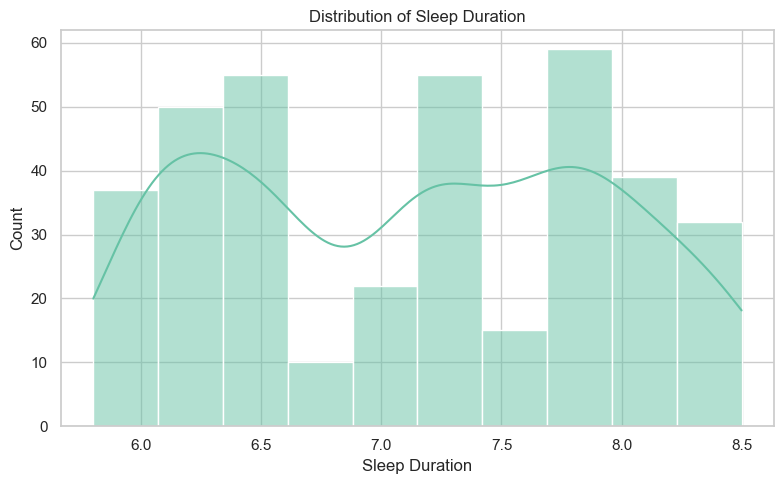

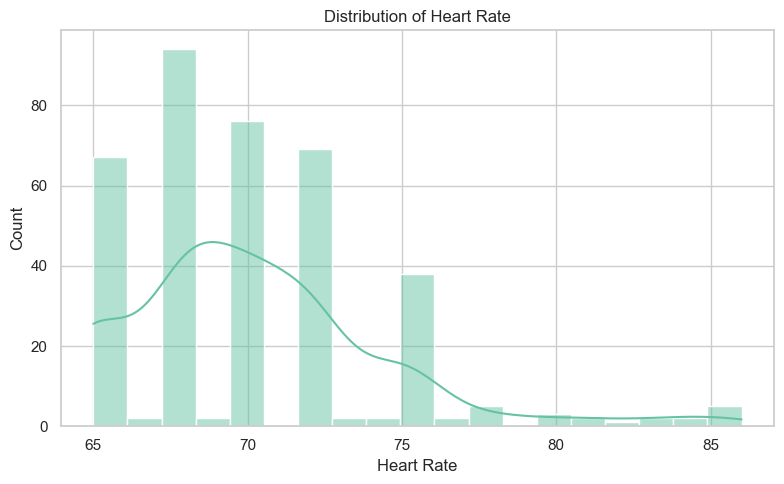

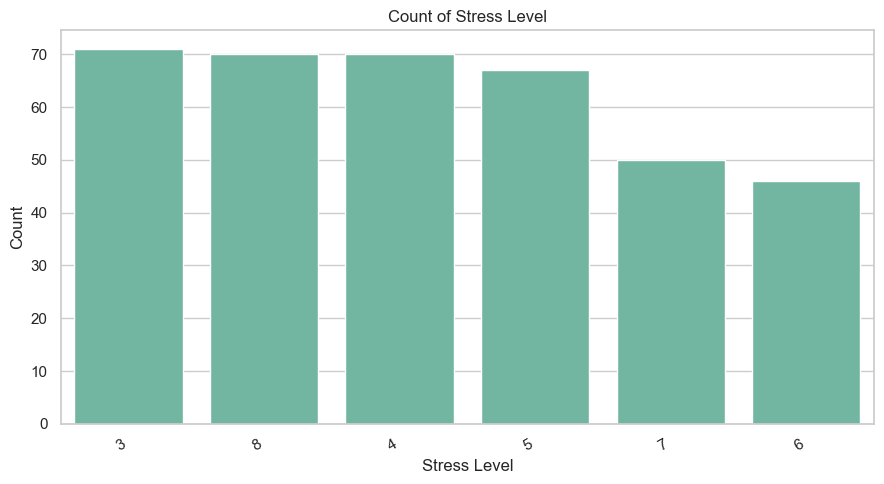

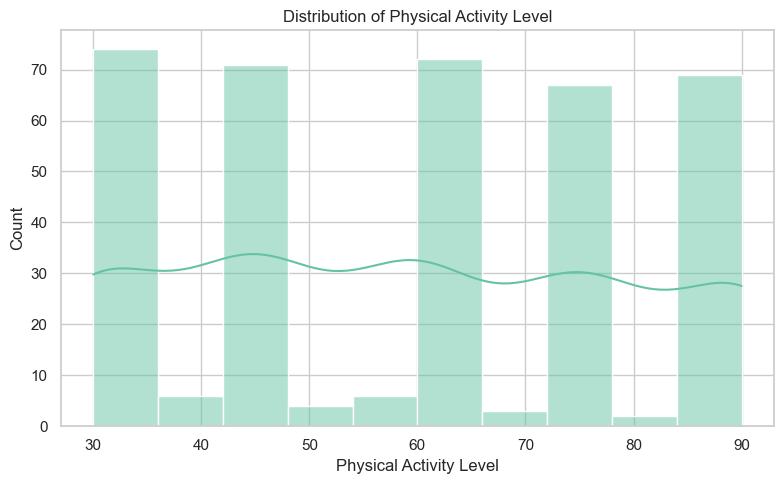

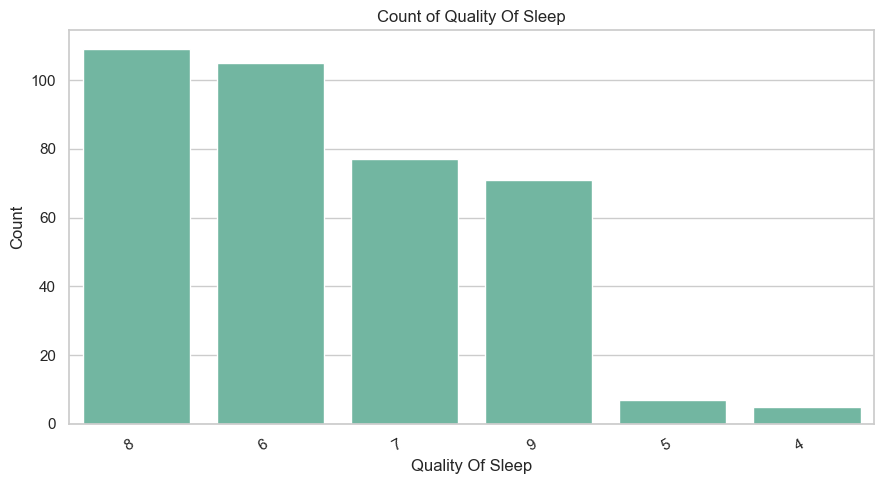

In [9]:
plot_research_variables(clean_df)

## 6. Correlation Analysis

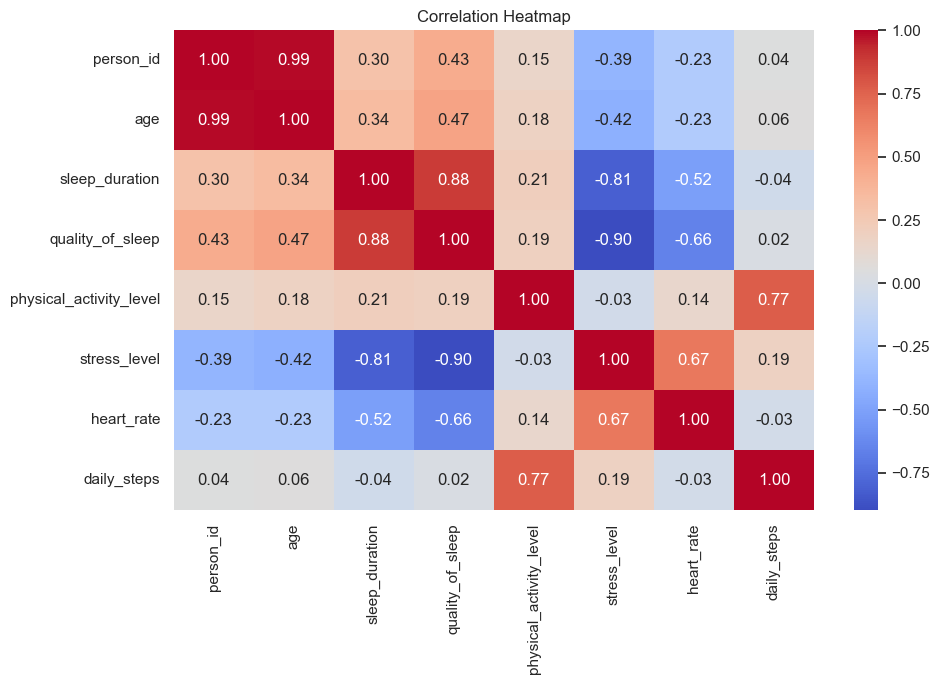

In [10]:
plot_correlation_heatmap(clean_df, filename="correlation_heatmap.png")

1. Sleep duration has a strong positive correlation with sleep quality (0.88), suggesting that longer sleep is associated with better rest quality.

2. Stress level shows a strong negative relationship with sleep quality (-0.90), indicating that stress significantly impacts sleep health.

3. Higher heart rate appears to correlate with reduced sleep quality (-0.66), which may support the idea that physiological stress affects sleep performance.

4. Physical activity level strongly correlates with daily steps (0.77), validating the consistency of activity-related metrics.

# Correlation Findings

1) Sleep duration strongly correlates with sleep quality.
2) Stress level negatively impacts sleep quality.
3) Heart rate appears associated with poorer sleep performance.
4) Physical activity correlates with daily steps and healthier sleep patterns.

## 7. Baseline Machine Learning Pipeline

The project tries to predict `Sleep Quality` first. If that is not available, it tries `Sleep Disorder`, then `Sleep Efficiency`.

In [11]:
X, y, target_column, task_type = prepare_features_and_target(clean_df)

print(f"Target column: {target_column}")
print(f"Task type: {task_type}")

if X is not None:
    print(f"Feature matrix shape: {X.shape}")
    display(X.head())

Target column: quality_of_sleep
Task type: classification
Feature matrix shape: (374, 11)


,gender,age,occupation,sleep_duration,physical_activity_level,stress_level,bmi_category,blood_pressure,heart_rate,daily_steps,sleep_disorder
0,1,27,9,6.1,42,6,3,11,77,4200,1
1,1,28,1,6.2,60,8,0,9,75,10000,1
2,1,28,1,6.2,60,8,0,9,75,10000,1
3,1,28,6,5.9,30,8,2,22,85,3000,1
4,1,28,6,5.9,30,8,2,22,85,3000,1


In [12]:
if X is not None and y is not None:
    trained_models, results = train_baseline_models(X, y, task_type)
    results
else:
    trained_models, results = {}, {}

In [13]:
for model_name, metrics in results.items():
    print(f"\nModel: {model_name}")
    for metric_name, metric_value in metrics.items():
        print(f"{metric_name}:")
        print(metric_value)


Model: logistic_regression
accuracy:
0.9466666666666667
classification_report:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         1
           6       0.84      1.00      0.91        21
           7       1.00      0.88      0.93        16
           8       1.00      1.00      1.00        22
           9       1.00      1.00      1.00        14

    accuracy                           0.95        75
   macro avg       0.64      0.65      0.64        75
weighted avg       0.93      0.95      0.93        75


Model: random_forest
accuracy:
0.9733333333333334
classification_report:
              precision    recall  f1-score   support

           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00        21
           7       1.00      1.00      1.00        16
           8       1.00      0.9

## 8. Save Best Model

In [14]:
best_model_name, best_model = choose_best_model(trained_models, results, task_type)

if best_model is not None:
    filename = f"{best_model_name}_{target_column}.pkl"
    save_model(best_model, filename, output_dir=PROJECT_ROOT / "outputs" / "models")

Model saved to c:\Users\fscen\research\smart-alarm-research\outputs\models\random_forest_quality_of_sleep.pkl


## 9. Research Notes

After running the notebook, write down:

- Which variables had the strongest correlations with sleep quality or efficiency?
- Which model performed better?
- What limitations exist in the dataset?
- How could this become a real smart alarm system with live smartwatch data?

# Final Conclusion

This research demonstrates that smartwatch and lifestyle-related metrics can be used to predict sleep quality with high accuracy.

The Random Forest model achieved the best performance with approximately 97% accuracy.

The findings suggest that wearable device data may support future AI-based smart alarm systems capable of improving wake-up timing and sleep optimization.